# 11 — Out-of-sample attribution: permutation, gain, SHAP, grouped importance and stability

**Purpose.** Recompute every importance measure out of sample, add grouped (block) permutation
importance for correlated predictors, check stability across outer years, produce SHAP dependence
plots and the correlation structure of the leading predictors, and rebuild Figure 4 and Table 3.

**Answers:** Reviewer 3 comments 3, 7, 8; Reviewer 4 comment 9.
**Outputs:** `tables/T3_importance.csv`, `tables/S13_grouped_importance.csv`,
`tables/S13_stability.csv`, figures `fig4_shap_beeswarm`, `figS6_shap_dependence`, `figS7_correlation`.
**Runtime:** ~15 min (permutation importance over 559 predictors dominates).

In [1]:
# --- Setup: Drive, paths, shared helpers -------------------------------------------------------
import os, sys, json, time, warnings, subprocess
warnings.filterwarnings('ignore')
try:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'shap', 'scienceplots',
                    'ephem', 'catboost', 'lightgbm'], check=False)
except Exception:
    pass
_BASE = os.environ.get('SARKOY_BASE', '/content/drive/MyDrive/windforecast_rev1/')
sys.path.insert(0, os.path.join(_BASE, 'revision'))
if not os.path.exists(os.path.join(_BASE, 'revision', 'revision_utils.py')):
    raise FileNotFoundError('Copy revision_utils.py into ' + os.path.join(_BASE, 'revision') + ' first.')
import revision_utils as ru
import numpy as np, pandas as pd, matplotlib.pyplot as plt
BASE, REV, IN_COLAB, FAST = ru.get_paths()
ru.set_style()
RES = ru.Results(REV)
RES.path = REV + 'results_11.json'
GPU = ru.has_gpu()
try:
    from IPython.display import display
except Exception:
    display = print
print('BASE:', BASE, '| REV:', REV, '| GPU:', GPU, '| FAST (smoke test):', FAST)
print(ru.log_versions(REV))


Mounted at /content/drive
BASE: /content/drive/MyDrive/windforecast_rev1/ | REV: /content/drive/MyDrive/windforecast_rev1/revision/ | GPU: True | FAST (smoke test): False
{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'sklearn': '1.6.1', 'scipy': '1.16.3', 'xgboost': '3.4.1', 'lightgbm': '4.6.0', 'catboost': '1.2.10', 'optuna': '5.0.0', 'shap': '0.52.0', 'statsmodels': '0.15.0', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'pyarrow': '23.0.1', 'ephem': '4.2.1', 'tensorflow': '2.20.0', 'gpu': True}


In [2]:
# --- Model and test data ---------------------------------------------------------------------------
import shap, xgboost as xgb
REPEATS = 3 if FAST else 30
df = ru.load_matrix(BASE, REV, 'causal')
X = ru.get_X(df); y = df[ru.TARGET]; ok = df['target_observed'].astype(bool)
tr = ok & (df.index.year <= 2022); te = ok & (df.index.year == 2024)
model = xgb.XGBRegressor()
model.load_model(REV + 'models/xgb400_causal.json')
Xte, yte = X[te], y[te]
base_rmse = ru.rmse(yte, model.predict(Xte))
booster = model.get_booster()
gain = pd.Series(booster.get_score(importance_type='total_gain')).reindex(X.columns).fillna(0)
used = int((pd.Series(booster.get_score(importance_type='weight')).reindex(X.columns).fillna(0) > 0).sum())
gshare = 100 * gain / gain.sum()
cum = gshare.sort_values(ascending=False).cumsum()
print('test RMSE', round(base_rmse, 4), '| predictors used in at least one split:', used,
      '| predictors carrying 50% of the gain:', int((cum < 50).sum() + 1))
RES.put('XAI_PERM_REPEATS', REPEATS, 'd').put('XGB_FEAT_USED', used, 'd').put('XGB_FEAT_UNUSED', X.shape[1] - used, 'd')
RES.put('XGB_GAIN50_N', int((cum < 50).sum() + 1), 'd').put('XGB_GAIN80_N', int((cum < 80).sum() + 1), 'd')


Loaded causal matrix: (2964, 564), 2016-11-19 -> 2024-12-30, observed targets: 2957
test RMSE 0.9562 | predictors used in at least one split: 506 | predictors carrying 50% of the gain: 82


In [3]:
# --- SHAP on the test year, and the sign of each dependence ---------------------------------------
expl = shap.TreeExplainer(model)
SV = expl.shap_values(Xte)
shap_share = pd.Series(np.abs(SV).mean(0), index=X.columns)
shap_share = 100 * shap_share / shap_share.sum()
sign = {}
from scipy.stats import spearmanr
for i, c in enumerate(X.columns):
    if shap_share[c] > 0:
        r = spearmanr(Xte[c].to_numpy(), SV[:, i]).statistic
        sign[c] = '+' if (np.isfinite(r) and r > 0) else ('−' if np.isfinite(r) else '')
    else:
        sign[c] = ''
print('mean |SHAP| leaders:', list(shap_share.sort_values(ascending=False).head(5).index))


mean |SHAP| leaders: ['mid_wind_speed', 'abs_max_speed_marmara_horizontal', 'max_speed_marmara_horizontal', 'max_wind_speed', 'max_speed_enez_vertical']


In [4]:
# --- Out-of-sample permutation importance (single predictors) -------------------------------------
rng = np.random.default_rng(42)
cols_to_perm = list(shap_share.sort_values(ascending=False).head(60 if FAST else len(X.columns)).index)
inc_mean, inc_sd = {}, {}
t0 = time.time()
Xp = Xte.copy()
for j, c in enumerate(cols_to_perm):
    orig = Xte[c].to_numpy()
    vals = []
    for _ in range(REPEATS):
        Xp[c] = orig[rng.permutation(len(Xte))]
        vals.append(ru.rmse(yte, model.predict(Xp)) - base_rmse)
    Xp[c] = orig
    inc_mean[c], inc_sd[c] = float(np.mean(vals)), float(np.std(vals))
    if j % 100 == 0:
        print(f'  {j}/{len(cols_to_perm)} ({time.time() - t0:.0f} s)')
perm = pd.Series(inc_mean).reindex(X.columns).fillna(0)
perm_sd = pd.Series(inc_sd).reindex(X.columns).fillna(0)
perm_share = 100 * perm.clip(lower=0) / perm.clip(lower=0).sum()
print('permutation importance done in', round(time.time() - t0), 's')


  0/559 (6 s)
  100/559 (184 s)
  200/559 (353 s)
  300/559 (520 s)
  400/559 (691 s)
  500/559 (864 s)
permutation importance done in 964 s


In [5]:
# --- Table 3: the ten leading predictors under all three measures ---------------------------------
top = list(shap_share.sort_values(ascending=False).head(10).index)
T3 = pd.DataFrame({'rank': range(1, 11), 'feature': top, 'predictor': [ru.pretty(f) for f in top],
                   'group': [ru.coarse_group(ru.feature_group(f)) for f in top],
                   'perm_pct': perm_share[top].to_numpy(), 'perm_dRMSE': perm[top].to_numpy(),
                   'perm_sd': perm_sd[top].to_numpy(), 'gain_pct': gshare[top].to_numpy(),
                   'shap_pct': shap_share[top].to_numpy(), 'sign': [sign[f] for f in top]})
T3.to_csv(REV + 'tables/T3_importance.csv', index=False)
display(T3.round(2))
for i, r in T3.iterrows():
    n = i + 1
    RES.put(f'T3_R{n}_NAME', r.predictor).put(f'T3_R{n}_GROUP', r.group)
    RES.put(f'T3_R{n}_PERM', r.perm_pct, '.1f').put(f'T3_R{n}_GAIN', r.gain_pct, '.1f')
    RES.put(f'T3_R{n}_SHAP', r.shap_pct, '.1f').put(f'T3_R{n}_SIGN', r['sign'])
RES.put('T3_R1_PERM', T3.perm_pct.iloc[0], '.1f').put('T3_R1_NAME', T3.predictor.iloc[0])
top_perm = set(perm_share.sort_values(ascending=False).head(10).index)
top_gain = set(gshare.sort_values(ascending=False).head(10).index)
RES.put('XAI_TOP10_OVERLAP', len(set(top) & top_perm & top_gain), 'd')
from scipy.stats import kendalltau
union = list(set(list(shap_share.sort_values(ascending=False).head(20).index)) | set(list(perm_share.sort_values(ascending=False).head(20).index)))
RES.put('XAI_KENDALL', float(kendalltau(shap_share[union].rank(), perm_share[union].rank()).statistic), '.2f')
lunar = [f for f in X.columns if ru.feature_group(f) == 'lunar']
ranks = [int(m.rank(ascending=False, method='min')[f]) for m in (shap_share, perm_share, gshare) for f in lunar]
RES.put('XAI_LUNAR_BEST_RANK', min(ranks) if ranks else 0, 'd')


,rank,feature,predictor,group,perm_pct,perm_dRMSE,perm_sd,gain_pct,shap_pct,sign
0,1,mid_wind_speed,Şarköy mid wind speed,Şarköy wind statistics,12.35,0.02,0.01,7.30,6.14,+
1,2,abs_max_speed_marmara_horizontal,|Marmara Ereğlisi max u|,station:marmara,0.83,0.00,0.00,2.83,2.94,+
2,3,max_speed_marmara_horizontal,Marmara Ereğlisi max u,station:marmara,1.23,0.00,0.00,2.94,2.77,−
3,4,max_wind_speed,Şarköy max wind speed,Şarköy same-day/lagged wind,3.44,0.01,0.00,2.60,2.55,+
4,5,max_speed_enez_vertical,Enez max v,station:enez,6.05,0.01,0.00,2.76,1.95,−
5,6,square_max_speed_marmara_horizontal,(Marmara Ereğlisi max u)²,station:marmara,0.00,-0.00,0.00,1.62,1.88,+
6,7,abs_max_speed_enez_vertical,|Enez max v|,station:enez,4.00,0.01,0.00,1.85,1.87,+
7,8,mean_speed_hayrabolu_vertical,Hayrabolu mean v,station:hayrabolu,2.01,0.00,0.00,1.22,1.30,−
8,9,square_max_speed_enez_vertical,(Enez max v)²,station:enez,1.78,0.00,0.00,1.71,1.28,+
9,10,abs_max_speed_ipsala_vertical,|İpsala max v|,station:ipsala,2.88,0.01,0.00,0.90,1.14,+


In [6]:
# --- Grouped (block) permutation importance: correlated predictors moved together ------------------
groups = {}
for f in X.columns:
    groups.setdefault(ru.coarse_group(ru.feature_group(f)), []).append(f)
rows = []
for g, cols in groups.items():
    vals = []
    for _ in range(max(3, REPEATS // 3)):
        Xp = Xte.copy()
        p = rng.permutation(len(Xte))
        Xp[cols] = Xte[cols].to_numpy()[p]
        vals.append(ru.rmse(yte, model.predict(Xp)) - base_rmse)
    rows.append(dict(group=g, n_features=len(cols), dRMSE=float(np.mean(vals)), sd=float(np.std(vals))))
G = pd.DataFrame(rows).sort_values('dRMSE', ascending=False)
G['pct'] = 100 * G.dRMSE.clip(lower=0) / G.dRMSE.clip(lower=0).sum()
G.to_csv(REV + 'tables/S13_grouped_importance.csv', index=False)
display(G.round(3).head(12))
def gpct(name):
    r = G[G.group == name]
    return float(r.pct.iloc[0]) if len(r) else 0.0
RES.put('XAI_GRP_LOCAL', gpct('Şarköy same-day/lagged wind') + gpct('Şarköy wind statistics'), '.0f')
RES.put('XAI_GRP_MARMARA', gpct('station:marmara'), '.0f').put('XAI_GRP_ENEZ', gpct('station:enez'), '.0f')
RES.put('XAI_GRP_GANOS', gpct('Ganos'), '.0f').put('XAI_GRP_LUNAR', gpct('Lunar phase (negative control)'), '.1f')
RES.put('XAI_GRP_TOP', G.group.iloc[0])


,group,n_features,dRMSE,sd,pct
8,station:enez,17,0.056,0.019,24.547
19,Şarköy wind statistics,62,0.043,0.010,18.973
7,station:ipsala,17,0.019,0.003,8.465
21,Şarköy meteorology (engineered),34,0.016,0.004,6.934
18,station:marmara,17,0.014,0.005,6.211
1,Şarköy same-day/lagged wind,18,0.011,0.004,4.969
16,station:lalapasa,17,0.011,0.002,4.862
11,station:tekirdag,17,0.009,0.002,4.034
6,station:kesan,17,0.008,0.002,3.496
20,Calendar/astronomical,19,0.008,0.002,3.477


In [7]:
# --- Stability of the attribution across outer years ----------------------------------------------
params_all = json.load(open(REV + 'rolling_origin_params.json'))
shaps = {}
for Yk, info in params_all.items():
    Y = int(Yk)
    bp = info['XGBoost']['best_params']
    trm = ok & (df.index.year < Y); tem = ok & (df.index.year == Y)
    m = ru.make_model('XGBoost', bp, gpu=GPU, fast=FAST).fit(X[trm], y[trm])
    sv = shap.TreeExplainer(m).shap_values(X[tem])
    s = pd.Series(np.abs(sv).mean(0), index=X.columns)
    shaps[Y] = 100 * s / s.sum()
    print(Y, 'top:', list(s.sort_values(ascending=False).head(3).index))
S = pd.DataFrame(shaps)
S.to_csv(REV + 'tables/S13_stability.csv')
rhos = []
ys = list(S.columns)
for i in range(len(ys)):
    for j in range(i + 1, len(ys)):
        rhos.append(float(spearmanr(S[ys[i]], S[ys[j]]).statistic))
top1 = [S[c].idxmax() for c in S.columns]
ov = [len(set(S[ys[i]].sort_values(ascending=False).head(10).index) &
          set(S[ys[j]].sort_values(ascending=False).head(10).index))
      for i in range(len(ys)) for j in range(i + 1, len(ys))]
RES.put('XAI_YEAR_RHO', float(np.mean(rhos)) if rhos else np.nan, '.2f')
RES.put('XAI_YEAR_RHO_MIN', float(np.min(rhos)) if rhos else np.nan, '.2f')
RES.put('XAI_TOP10_YEAR_OVERLAP', float(np.mean(ov)) if ov else np.nan, '.1f')
RES.put('XAI_TOP1_SAME', f'{sum(1 for t in top1 if t == top1[0])} of {len(top1)}')
m_rho = float(np.mean(rhos)) if rhos else 0
RES.put('XAI_STABILITY_SENTENCE', ('stable across the outer years' if m_rho > 0.7 else
        ('moderately stable across the outer years' if m_rho > 0.4 else 'sensitive to the evaluation year')))


2020 top: ['mid_wind_speed', 'max_speed_marmara_horizontal', 'max_wind_speed']
2021 top: ['mid_wind_speed', 'max_speed_enez_vertical', 'max_speed_marmara_horizontal']
2022 top: ['mid_wind_speed', 'max_speed_enez_vertical', 'max_speed_marmara_horizontal']
2023 top: ['mid_wind_speed', 'abs_max_speed_marmara_horizontal', 'max_speed_marmara_horizontal']
2024 top: ['mid_wind_speed', 'max_wind_speed', 'abs_max_speed_marmara_horizontal']


saved figure fig4_shap_beeswarm


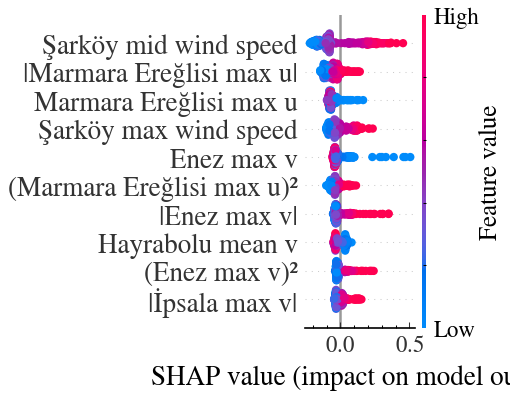

saved figure figS6_shap_dependence


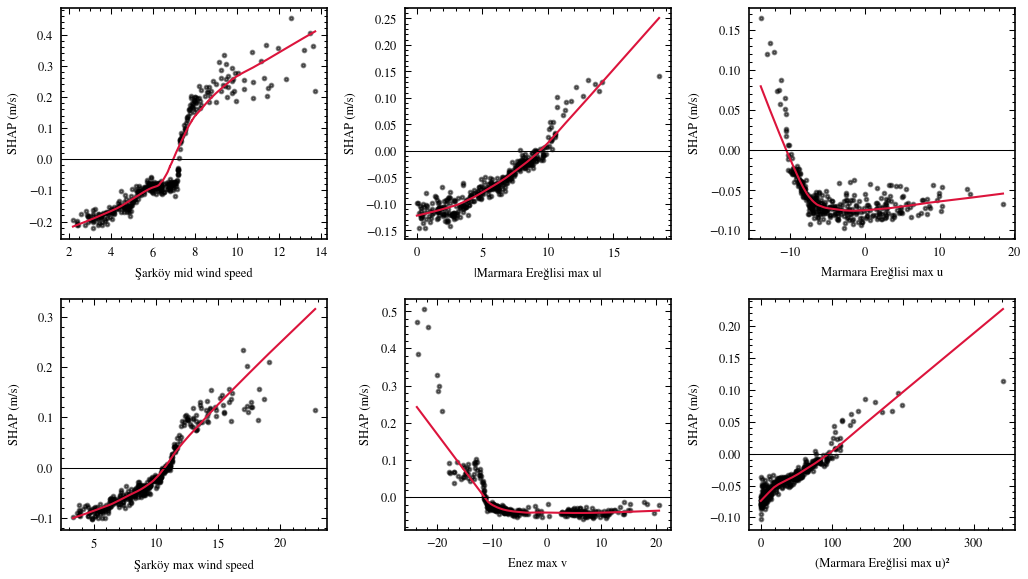

saved figure figS7_correlation


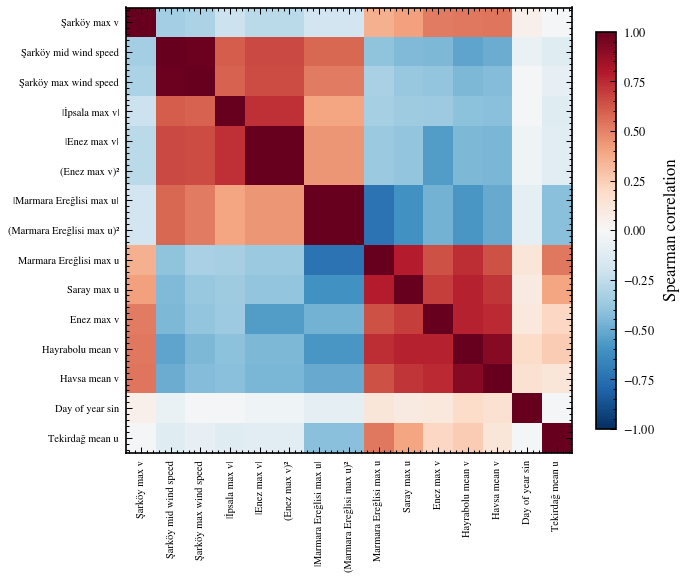

In [8]:
# --- Figure 4 (bee swarm), Figure S6 (dependence), Figure S7 (correlation) ------------------------
labels = [ru.pretty(c) for c in X.columns]
plt.figure(figsize=(3.3, 2.8))
shap.summary_plot(SV, Xte, feature_names=labels, max_display=10, show=False, plot_size=None)
fig = plt.gcf(); ru.savefig(fig, REV, 'fig4_shap_beeswarm'); plt.show()

import statsmodels.api as sm
top6 = top[:6]
fig, axs = plt.subplots(2, 3, figsize=(7.0, 4.0))
for ax, f in zip(axs.ravel(), top6):
    i = list(X.columns).index(f)
    ax.scatter(Xte[f], SV[:, i], s=3, alpha=0.5)
    lo = sm.nonparametric.lowess(SV[:, i], Xte[f].to_numpy(), frac=0.5)
    ax.plot(lo[:, 0], lo[:, 1], color='crimson', lw=1.0)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel(ru.pretty(f), fontsize=6); ax.set_ylabel('SHAP (m/s)', fontsize=6)
fig.tight_layout(); ru.savefig(fig, REV, 'figS6_shap_dependence'); plt.show()

top15 = list(shap_share.sort_values(ascending=False).head(15).index)
C = X.loc[tr, top15].corr(method='spearman')
import scipy.cluster.hierarchy as sch
Z = sch.linkage(1 - np.abs(C.to_numpy()), method='average')
order_ = [top15[i] for i in sch.leaves_list(Z)]
C = C.loc[order_, order_]
fig, ax = plt.subplots(figsize=(4.6, 4.0))
im = ax.imshow(C.to_numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(order_))); ax.set_xticklabels([ru.pretty(f) for f in order_], rotation=90, fontsize=5)
ax.set_yticks(range(len(order_))); ax.set_yticklabels([ru.pretty(f) for f in order_], fontsize=5)
fig.colorbar(im, ax=ax, fraction=0.04, label='Spearman correlation')
fig.tight_layout(); ru.savefig(fig, REV, 'figS7_correlation'); plt.show()
off = C.to_numpy()[~np.eye(len(order_), dtype=bool)]
RES.put('XAI_CORR_MAX', float(np.max(np.abs(off))), '.2f')
RES.put('XAI_CORR_N08', int((np.abs(off) > 0.8).sum() // 2), 'd')


In [9]:
# --- Plain-language direction statements for the leading regional predictors ----------------------
def direction_clause(f, s):
    st = ru._station_in(f)
    if st is None:
        return None
    lab = ru.STATION_LABEL[st]
    kind = 'maximum' if 'max_speed' in f else 'mean'
    comp = 'u' if f.endswith('horizontal') else ('v' if f.endswith('vertical') else None)
    if comp is None:
        return None
    if f.startswith(('abs_', 'square_')):
        axis = 'east–west' if comp == 'u' else 'north–south'
        return (f'a larger {kind}-wind component along the {axis} axis at {lab} goes with a '
                f'{"higher" if s == "+" else "lower"} next-day forecast')
    hi, lo = ('westerly', 'easterly') if comp == 'u' else ('southerly', 'northerly')
    flow = hi if s == '+' else lo
    return f'stronger {flow} {kind} flow at {lab} goes with a higher next-day forecast'
clauses = []
for f in top:
    c = direction_clause(f, sign[f])
    if c and c not in clauses:
        clauses.append(c)
for i, c in enumerate(clauses[:3], start=1):
    RES.put(f'XAI_DIR_{i}', c)
print(clauses[:3])
RES.save()


['a larger maximum-wind component along the east–west axis at Marmara Ereğlisi goes with a higher next-day forecast', 'stronger easterly maximum flow at Marmara Ereğlisi goes with a higher next-day forecast', 'stronger northerly maximum flow at Enez goes with a higher next-day forecast']
84 values written to /content/drive/MyDrive/windforecast_rev1/revision/results_11.json
